In [1]:
import geemap
import xarray as xr
import time
import glob
import pandas as pd
import ultraplot as plot
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import calendar

In [2]:
dir = 'output'

## SATELITE DS

In [3]:
ds = xr.open_dataset(f'{dir}/precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2022-01.nc')
ds.values

Overwriting 'balance' that was already registered


<bound method Mapping.values of <xarray.Dataset> Size: 29MB
Dimensions:        (time: 31, lon: 301, lat: 260)
Coordinates:
  * time           (time) datetime64[ns] 248B 2022-01-01 ... 2022-01-10
  * lon            (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.06 -28.91
  * lat            (lat) float64 2kB -33.68 -33.53 -33.38 ... 4.875 5.025 5.175
Data variables:
    precip_chirps  (time, lon, lat) float32 10MB ...
    precip_imerge  (time, lon, lat) float32 10MB ...
    precip_gsmap   (time, lon, lat) float32 10MB ...
Attributes:
    crs:      EPSG:4326>

In [4]:
#juntar todos os meses .nc em um anual
ds22 = xr.open_mfdataset(f'{dir}/precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2022-*.nc', combine='nested', concat_dim='time')
ds23 = xr.open_mfdataset(f'{dir}/precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2023-*.nc', combine='nested', concat_dim='time')
ds24 = xr.open_mfdataset(f'{dir}/precipitacao_diaria_brasil_chirps_imerge_gsmap_15km_2024-*.nc', combine='nested', concat_dim='time')
dsall = xr.concat([ds22, ds23, ds24], dim='time')


In [5]:
chirps22 = ds22['precip_chirps']
chirps23 = ds23['precip_chirps']
chirps24 = ds24['precip_chirps']    

imerge22 = ds22['precip_imerge']
imerge23 = ds23['precip_imerge']
imerge24 = ds24['precip_imerge']

gsmap22 = ds22['precip_gsmap']
gsmap23 = ds23['precip_gsmap']
gsmap24 = ds24['precip_gsmap']


#chirps.mean('time').plot(x = 'lon',y = 'lat',col_wrap = 5,robust = True,cmap = 'jet',vmin = 0.1,vmax = 15)
#imerge.mean('time').plot(x = 'lon',y = 'lat',col_wrap = 5,robust = True,cmap = 'jet',vmin = 0.1,vmax = 15)
#gsmap.mean('time').plot(x = 'lon',y = 'lat',col_wrap = 5,robust = True,cmap = 'jet',vmin = 0.1,vmax = 15)

In [6]:
media_chirps22 = chirps22.sum('time')
media_chirps23 = chirps23.sum('time')
media_chirps24 = chirps24.sum('time')

media_imerge22 = imerge22.sum('time')
media_imerge23 = imerge23.sum('time')
media_imerge24 = imerge24.sum('time')

media_gsmap22 = gsmap22.sum('time')
media_gsmap23 = gsmap23.sum('time')
media_gsmap24 = gsmap24.sum('time')

### plot satelite

In [7]:
import salem
# leitura do shapefile com a biblioteca SALEM
shp = salem.read_shapefile('shape/BRAZIL.shp')
# seleciona os limites da imagem
lonmin = float(shp['min_x'])
lonmax = float(shp['max_x'])

latmin = float(shp['min_y'])
latmax = float(shp['max_y'])


C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2338323209.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lonmin = float(shp['min_x'])
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2338323209.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lonmax = float(shp['max_x'])
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2338323209.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latmin = float(shp['min_y'])
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2338323209.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latmax = float(shp['max_y'])


C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2334321128.py:5: UltraPlotWarning: The rc setting 'small' was deprecated in version 0.6.0 and may be removed in the next major release (version 2.0.0). Please use 'font.smallsize' instead.
  ax.format(labels=True,
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2334321128.py:5: UltraPlotWarning: The rc setting 'large' was deprecated in version 0.6.0 and may be removed in the next major release (version 2.0.0). Please use 'font.largesize' instead.
  ax.format(labels=True,
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2334321128.py:5: UltraPlotWarning: The rc setting 'small' was deprecated in version 0.6.0 and may be removed in the next major release (version 2.0.0). Please use 'font.smallsize' instead.
  ax.format(labels=True,
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\2334321128.py:5: UltraPlotWarning: The rc setting 'large' was deprecated in version 0.6.0 and may be removed in the next major release (version 2.0.0). Please use

SubplotGrid(nrows=1, ncols=1, length=1)

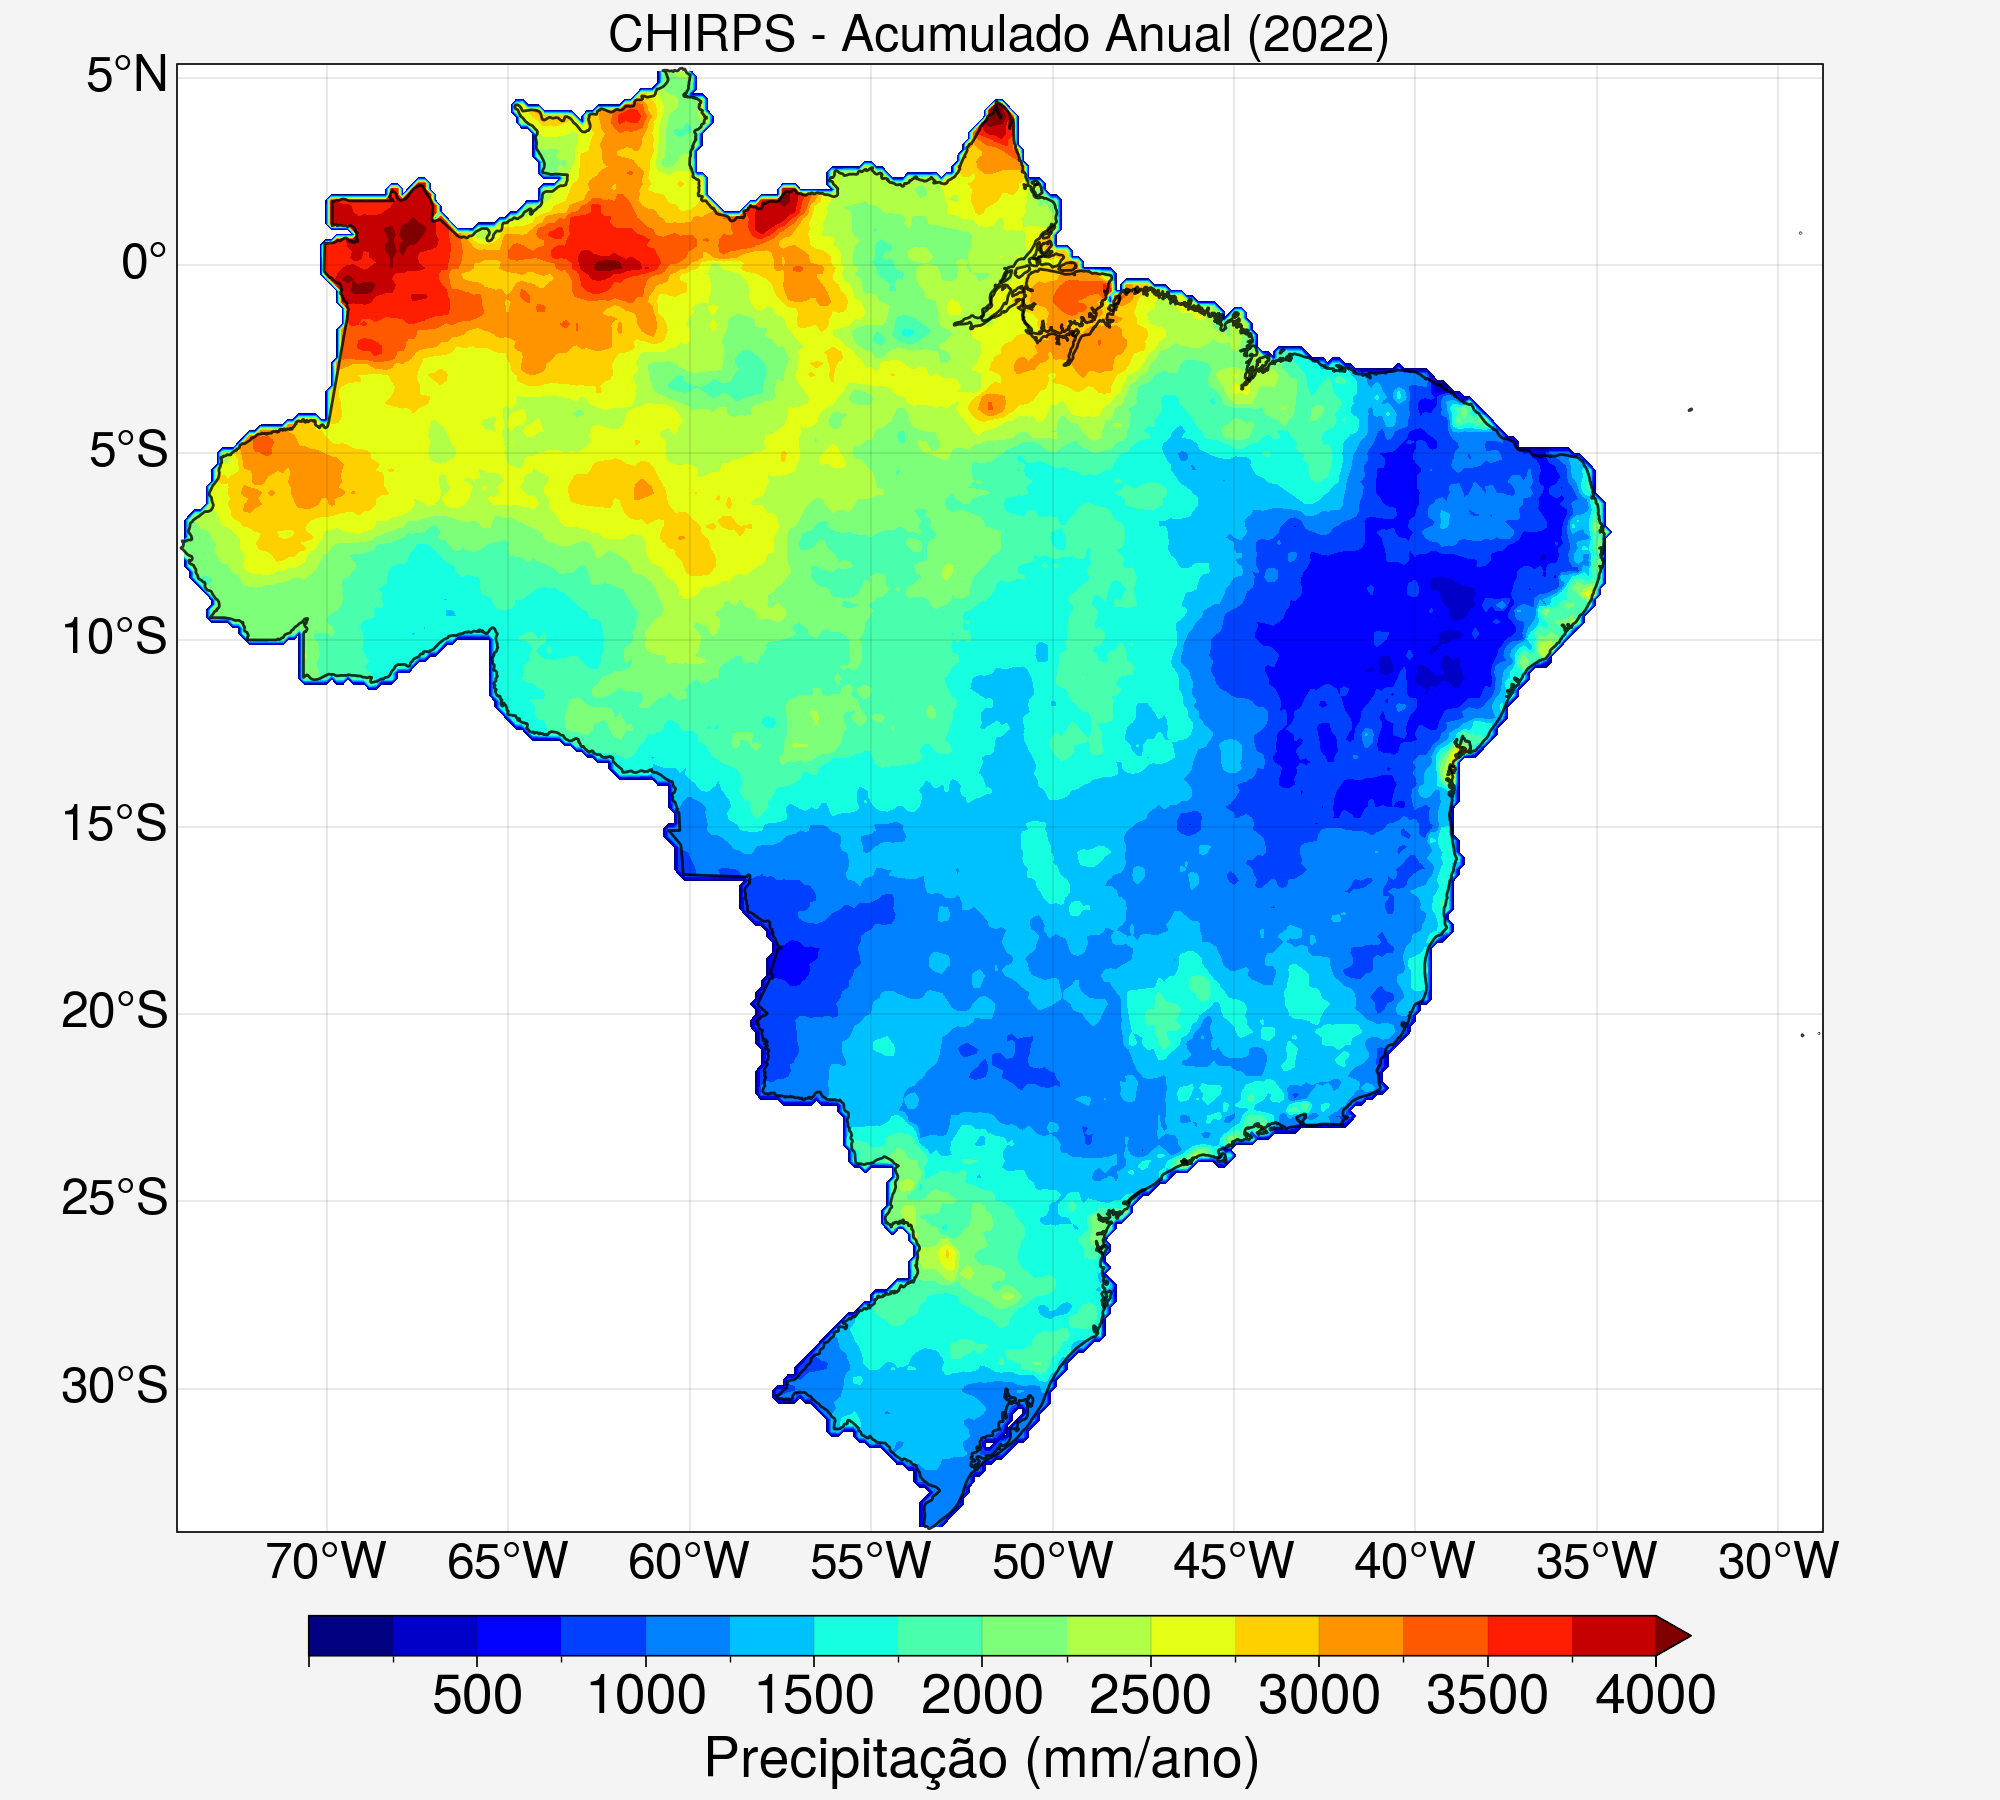

In [8]:

# Plotando a figura
fig, ax = plot.subplots(figsize=(10,9), tight=True, proj='pcarree')

# formatação dos eixos
ax.format(labels=True,
          latlines=5, lonlines=5,
          latlim=(latmin-0.10, latmax+0.10), lonlim=(lonmin-0.10, lonmax+0.10),
          small='25px', large='25px',
          title = f'CHIRPS - Acumulado Anual (2022)'
          )
# plota figura
map1 = ax.contourf(
    media_chirps22['lon'],
    media_chirps22['lat'],
    media_chirps22.values.T,
    cmap='jet',
    levels=plot.arange(0.01, 4000, 250),
    extend='max'
)


# plota barra de cores da figura
fig.colorbar(map1, loc='b', label='Precipitação (mm/ano)', ticks=500, ticklabelsize=20, labelsize=20, length=0.70)

# plota contorno do Estado
shp.plot(edgecolor='black', facecolor='none', linewidth=1, alpha=0.8, ax=ax)
# salva figura
#fig.savefig('output/Fig1_chirps_media_anual.png', dpi=300)

In [9]:
# leitura do shapefile com a biblioteca SALEM
shp = salem.read_shapefile('shape/BRAZIL.shp')

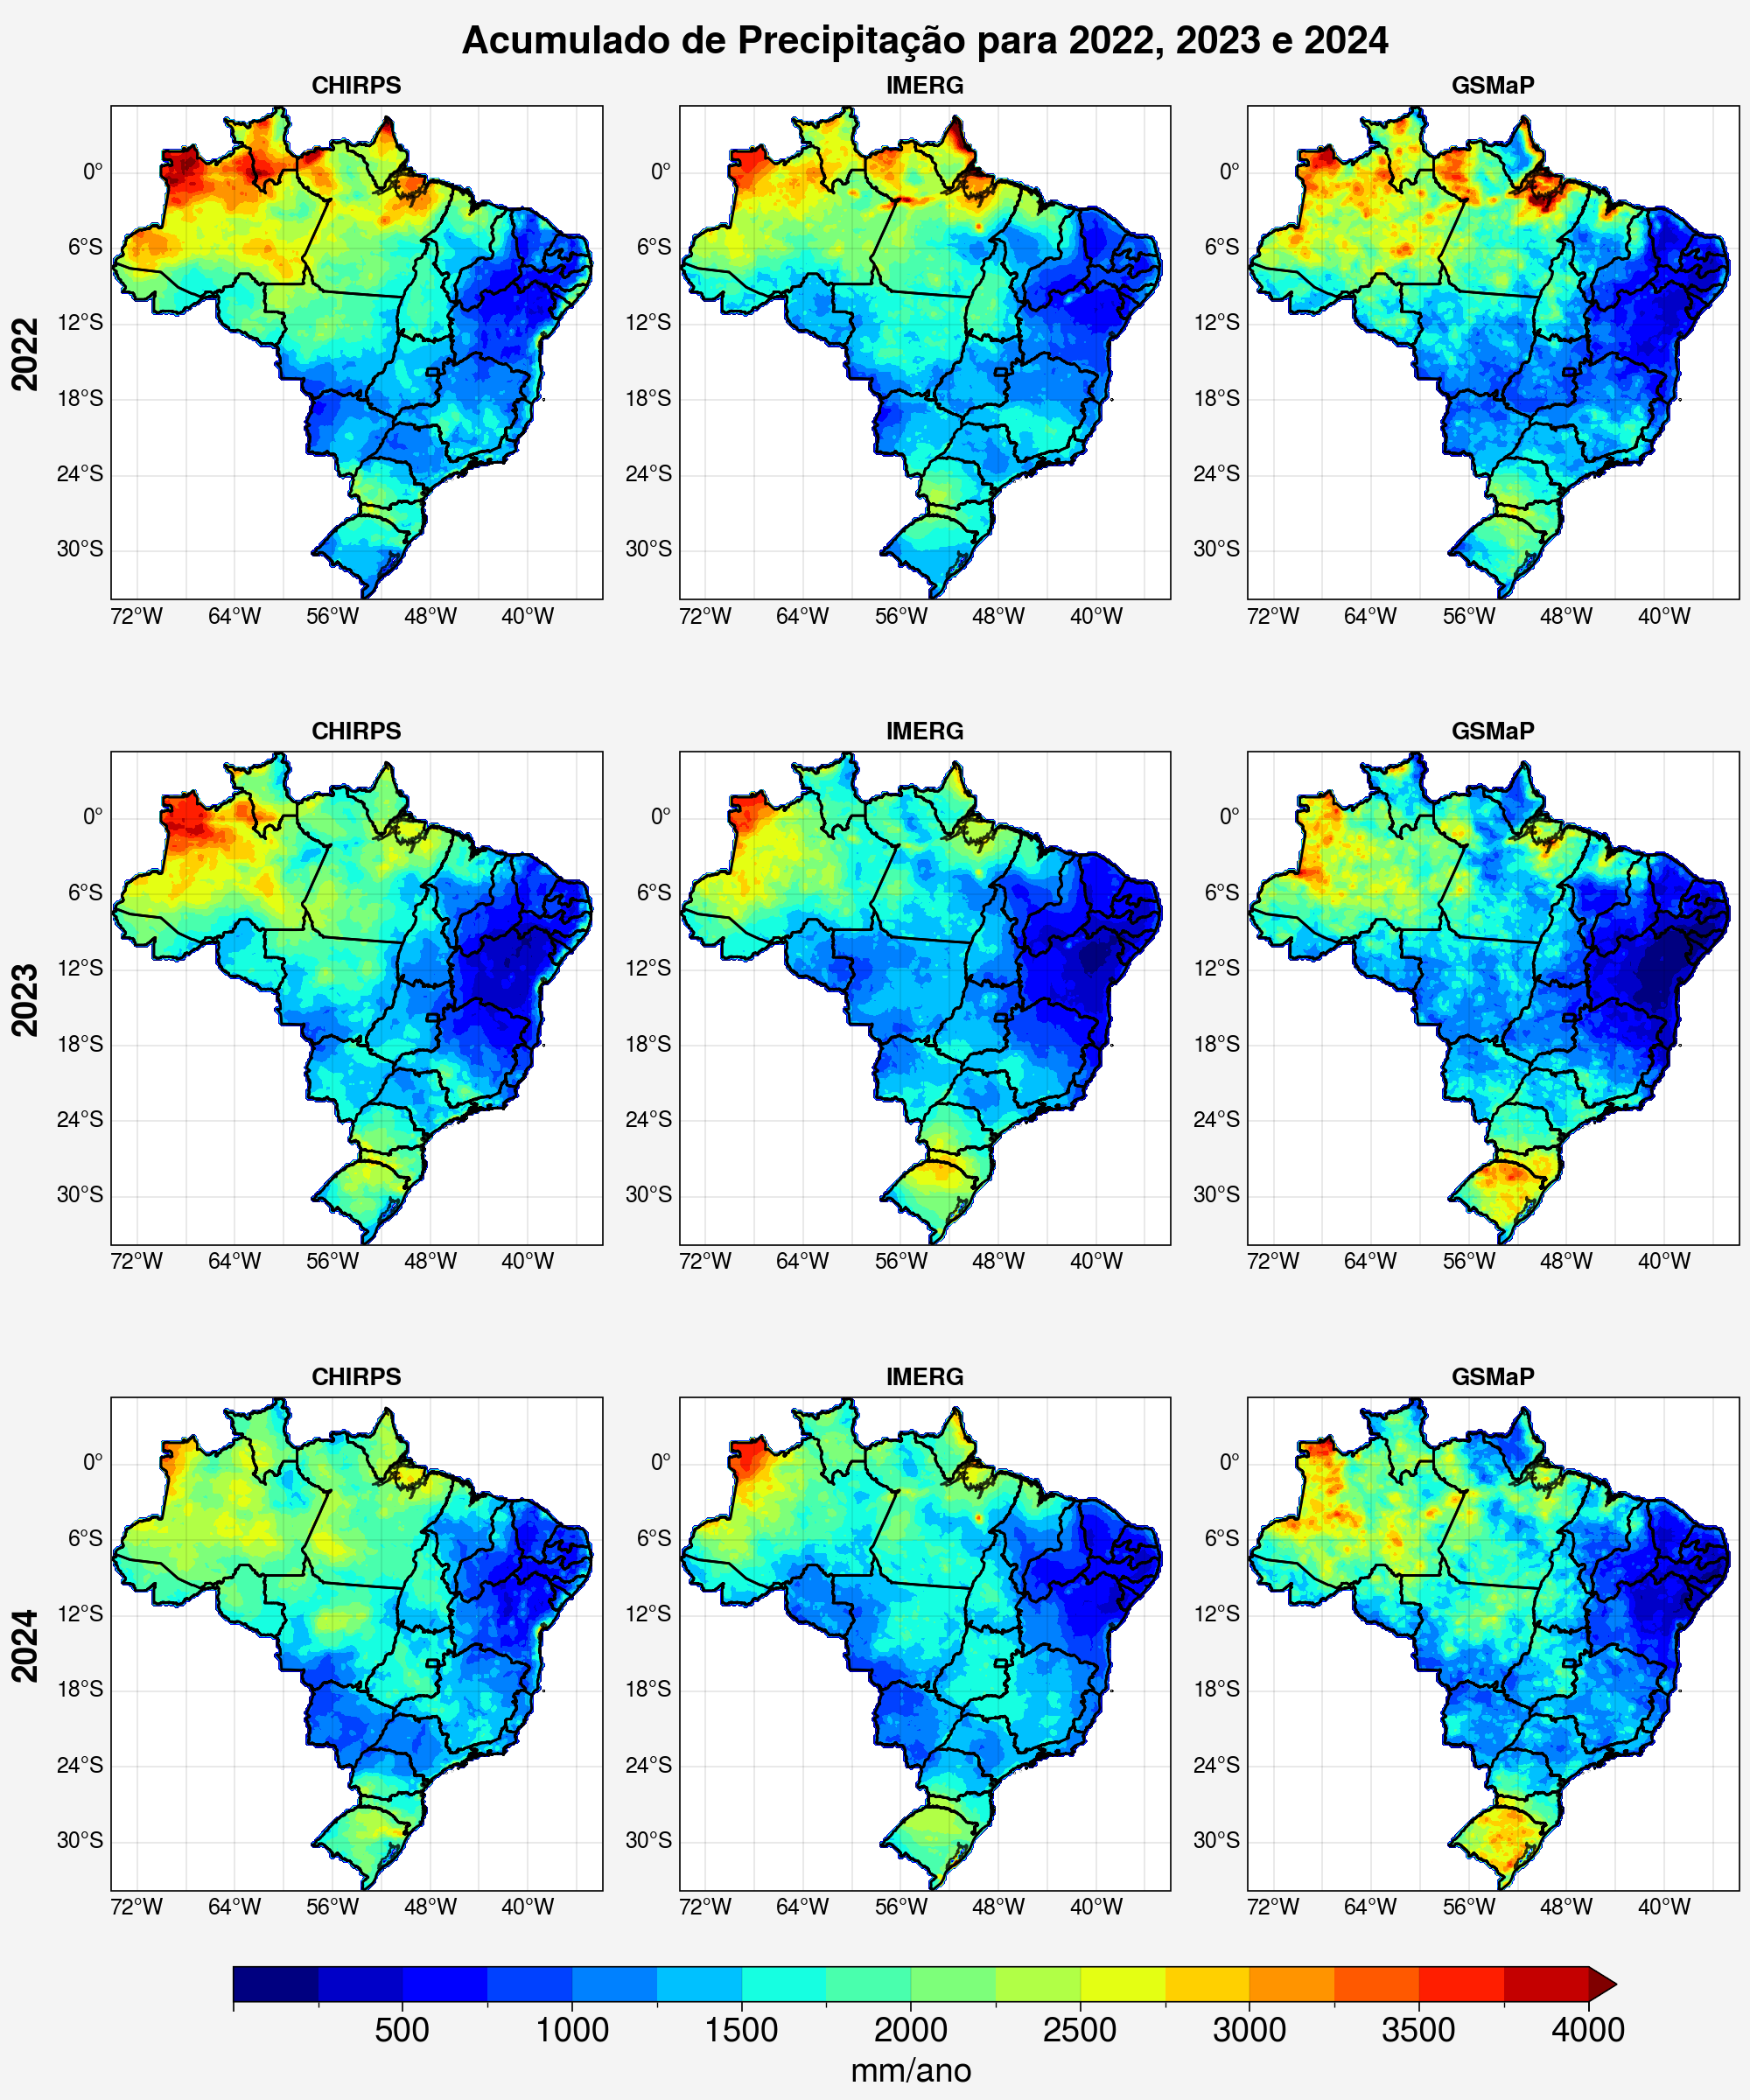

In [10]:
# --- Cria figura com eixos compartilhados ---
fig, axs = plot.subplots(
    ncols=3,
    nrows=3,
    figsize=(10, 12),
    proj='pcarree',
    tight=True,
)

# Lista de dados e títulos
datasets = [
    (media_chirps22, 'CHIRPS', 2022),
    (media_imerge22, 'IMERG', 2022),
    (media_gsmap22, 'GSMaP', 2022),
    
    (media_chirps23, 'CHIRPS', 2023),
    (media_imerge23, 'IMERG', 2023),
    (media_gsmap23, 'GSMaP', 2023),
    
    (media_chirps24, 'CHIRPS', 2024),
    (media_imerge24, 'IMERG', 2024),
    (media_gsmap24, 'GSMaP', 2024),
]

for ax, (data, nome, ano) in zip(axs, datasets):
    ax.format(coast=False, borders=False, innerborders=False,
        latlines=6, lonlines=4,
        latlim=(latmin - 0.10, latmax + 0.10),
        lonlim=(lonmin - 0.10, lonmax - 5),
        title=f'{nome}',
        titleweight='bold',
    )

    ax.format(labels = ['left', 'bottom'])
    
    # --- Plota o mapa ---
    mapplot = ax.contourf(
        data['lon'], data['lat'], data.values.T,
        cmap='jet',
        levels=plot.arange(0.01, 4000, 250),
        extend='max'
    )

    # --- Contorno do shapefile ---
    shp.plot(
        edgecolor='black',
        facecolor='none',
        linewidth=0.8,
        alpha=0.8,
        ax=ax
    )
    shapefile = list(shpreader.Reader('https://github.com/evmpython/CAT010_UNIFEI_2024/raw/main/shapefiles/BR_UF_2019.shp').geometries())
    ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)

# Adicione a linha 'leftlabels'
axs.format(
    leftlabels=['2022', '2023', '2024'], # Rótulos para cada linha, na esquerda
    leftlabels_kw={'size': 14, 'weight': 'bold'} # Estilo (opcional)
)
# shapefile dos estados



# --- Barra de cores compartilhada ---
fig.colorbar(
    mapplot,
    loc='b',
    label='mm/ano',
    ticks=500,
    ticklabelsize=14,
    labelsize=14,
    length=0.85
)

# --- Título geral do painel ---
fig.format(
    suptitle='Acumulado de Precipitação para 2022, 2023 e 2024',
    suptitlesize='22px',
    suptitleweight='bold'
)

plot.show()

In [11]:
dsall

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 1096, lon: 301, lat: 260)
Coordinates:
  * time           (time) datetime64[ns] 9kB 2022-01-01 ... 2024-12-10
  * lon            (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.06 -28.91
  * lat            (lat) float64 2kB -33.68 -33.53 -33.38 ... 4.875 5.025 5.175
Data variables:
    precip_chirps  (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
    precip_imerge  (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
    precip_gsmap   (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [12]:
imerge = dsall['precip_imerge'].sortby('time')
gsmap = dsall['precip_gsmap'].sortby('time')
chirps = dsall['precip_chirps'].sortby('time')

imerge

<xarray.DataArray 'precip_imerge' (time: 1096, lon: 301, lat: 260)> Size: 343MB
dask.array<getitem, shape=(1096, 301, 260), dtype=float32, chunksize=(30, 301, 260), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 9kB 2022-01-01 2022-01-02 ... 2024-12-31
  * lon      (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.21 -29.06 -28.91
  * lat      (lat) float64 2kB -33.68 -33.53 -33.38 -33.23 ... 4.875 5.025 5.175
Attributes:
    id:             precip_imerge
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]
    bounds:         [-73.98552953 -33.75040078 -28.847695     5.26487847]

In [13]:
#soma todos os dias do mes
chirps_monthly = chirps.resample(time='1M').sum()
gsmap_monthly = gsmap.resample(time='1M').sum()
imerge_monthly = imerge.resample(time='1M').sum()

chirps_monthly

c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'precip_chirps' (time: 36, lon: 301, lat: 260)> Size: 11MB
dask.array<stack, shape=(36, 301, 260), dtype=float32, chunksize=(1, 301, 260), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.21 -29.06 -28.91
  * lat      (lat) float64 2kB -33.68 -33.53 -33.38 -33.23 ... 4.875 5.025 5.175
  * time     (time) datetime64[ns] 288B 2022-01-31 2022-02-28 ... 2024-12-31
Attributes:
    id:             precip_chirps
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]
    bounds:         [-73.98552953 -33.75040078 -28.847695     5.26487847]

In [14]:
#media mensal anual
chirps_monthly_mean = chirps_monthly.groupby('time.month').mean('time')
gsmap_monthly_mean = gsmap_monthly.groupby('time.month').mean('time')
imerge_monthly_mean = imerge_monthly.groupby('time.month').mean('time') 

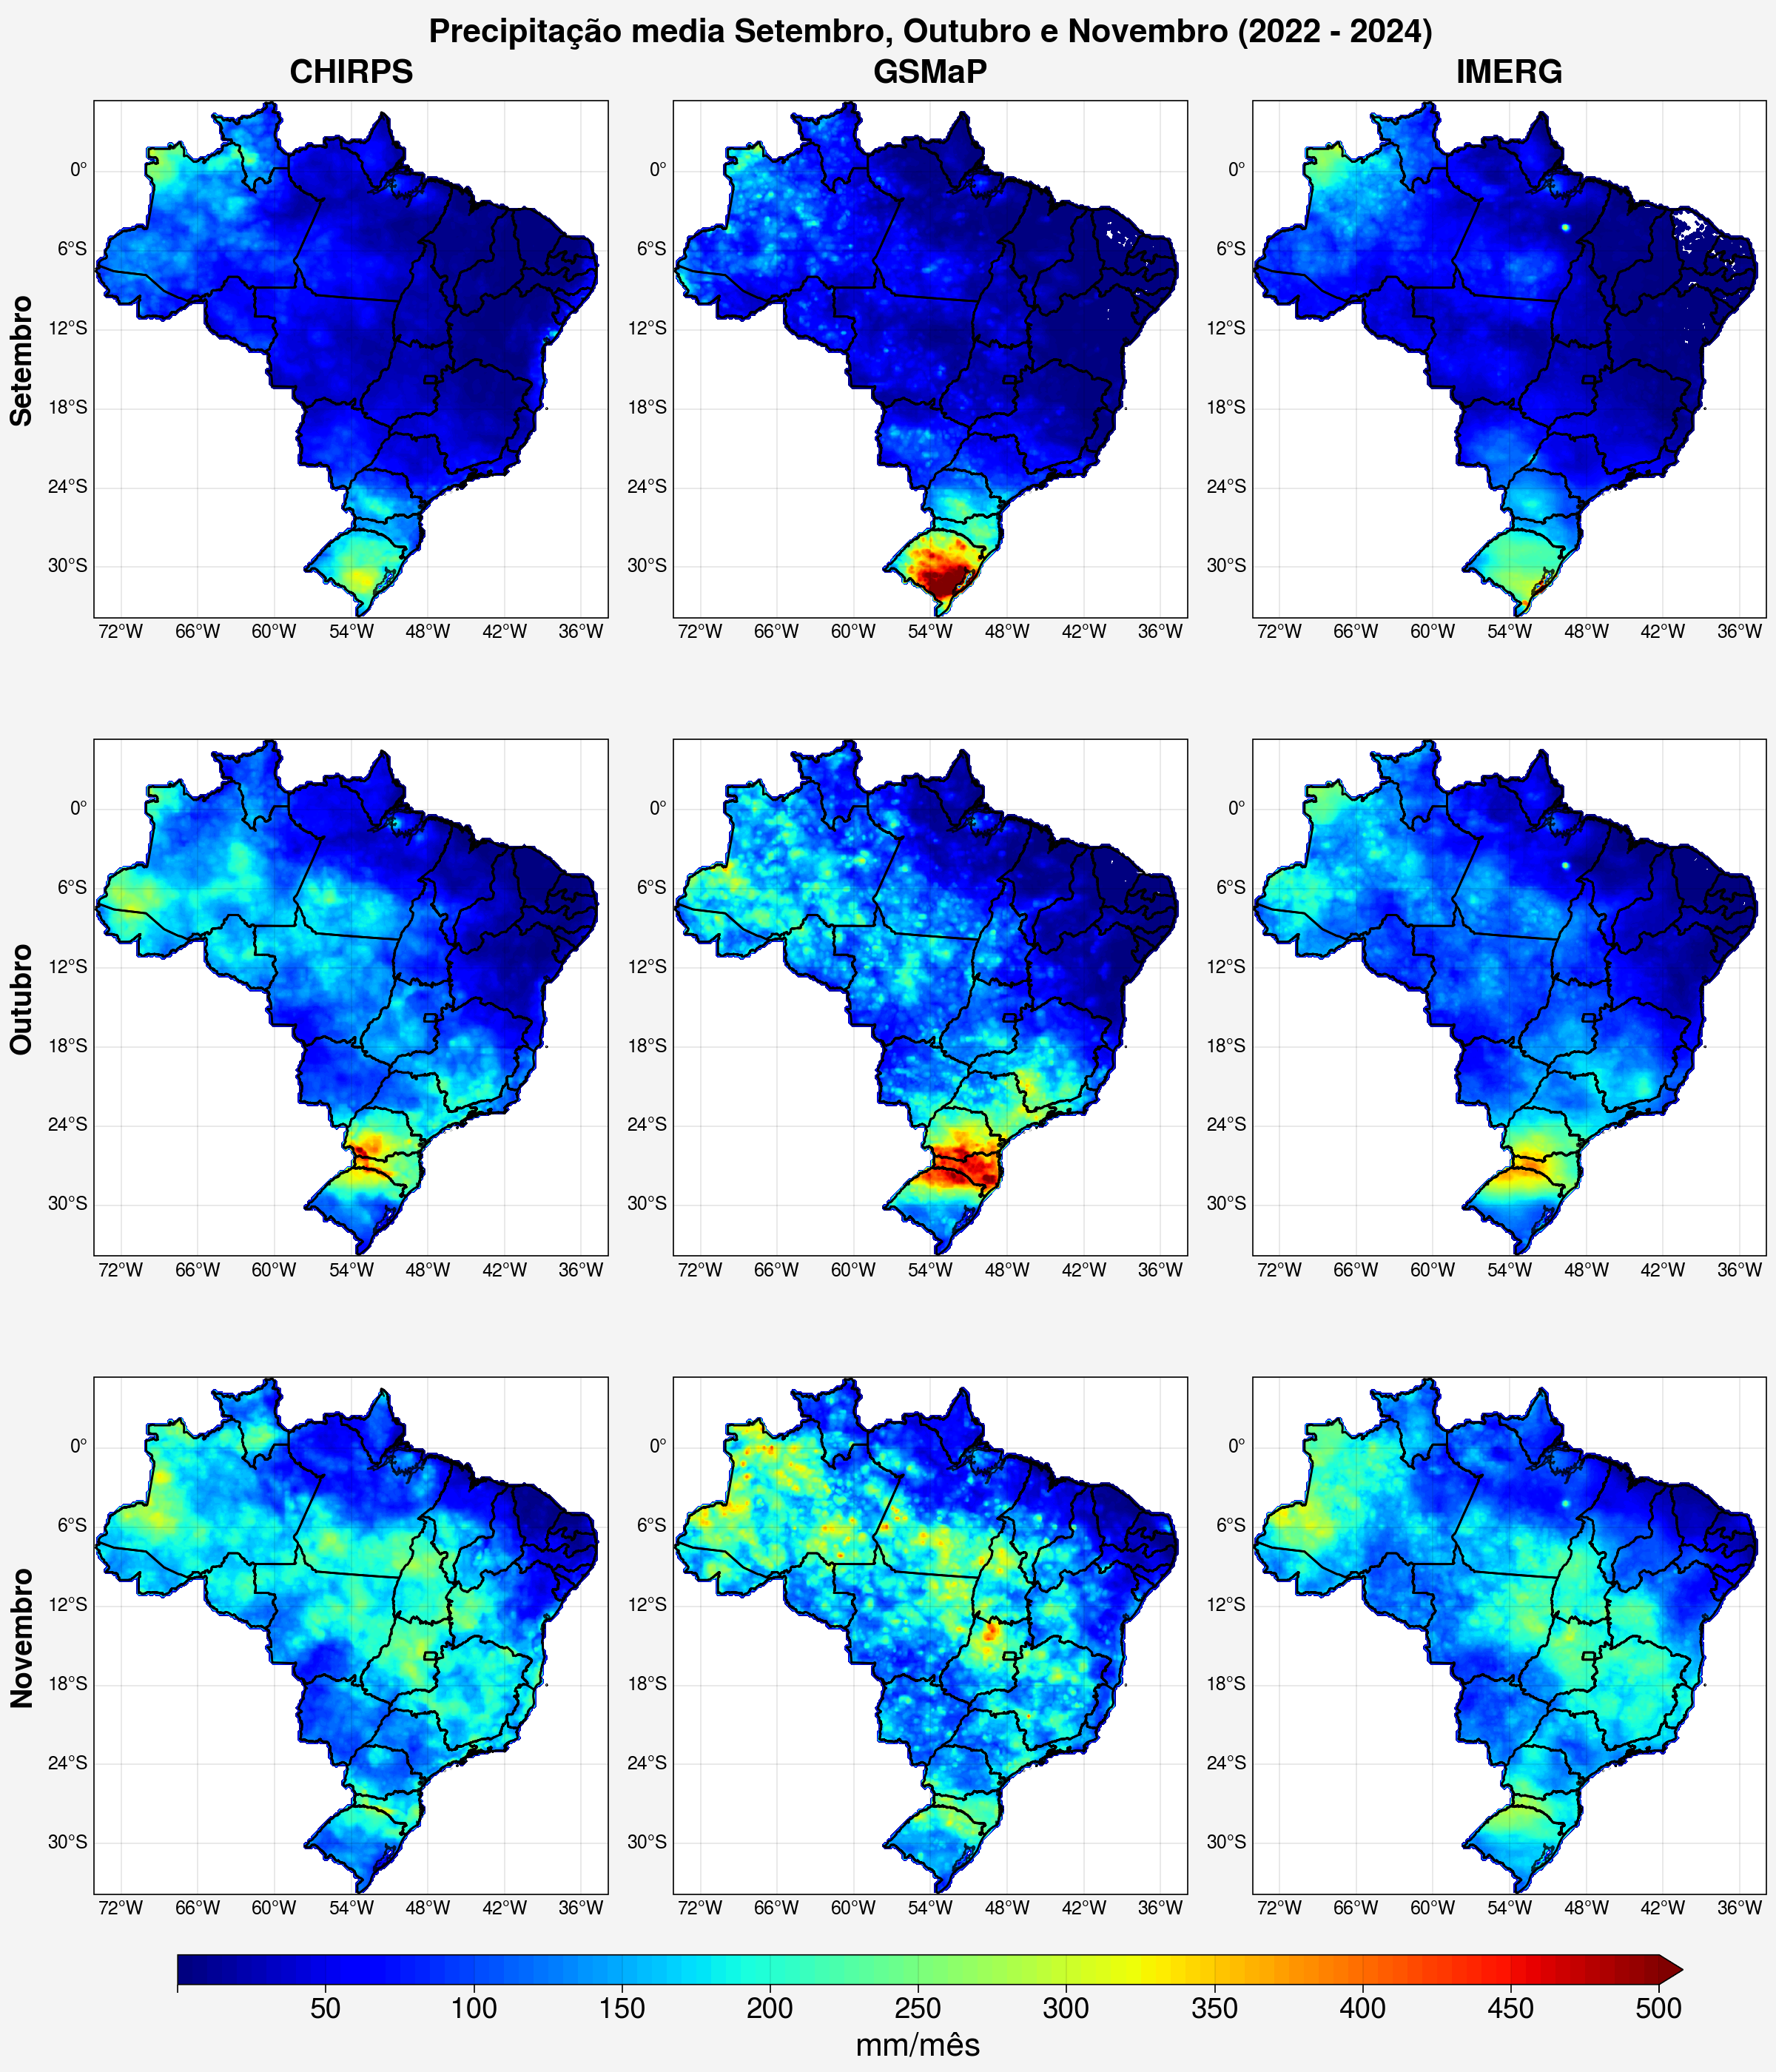

In [15]:
# --- Cria figura com eixos compartilhados ---
fig, axs = plot.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 14),
    proj='pcarree',
    tight=True,
)

# --- Lista de dados e títulos para as colunas ---
datasets = [
    (chirps_monthly_mean, 'CHIRPS'),
    (gsmap_monthly_mean, 'GSMaP'),
    (imerge_monthly_mean, 'IMERG'),
]

# --- Nomes dos meses para as linhas ---
meses_nomes = [#'Dezembro', 'Janeiro', 'Fevereiro',
                #'Março', 'Abril', 'Maio', 
                #'Junho','Julho', 'Agosto', 
               'Setembro', 'Outubro', 'Novembro'
               ]
meses_indices = [#12, 1, 2
                  #3, 4, 5,
                  #6, 7, 8,
                  9, 10, 11
                ]

#--- Loop aninhado para iterar sobre meses (linhas) e datasets (colunas) ---
for mes_idx, mes_nome in enumerate(meses_nomes):
    for data_idx, (data, nome) in enumerate(datasets):
        
        ax = axs[mes_idx, data_idx]

        # Seleciona o mês correto (dezembro → janeiro → fevereiro)
        dados_do_mes = data.sel(month=meses_indices[mes_idx])

        dados_corrigidos = dados_do_mes.transpose('lat', 'lon')

        ax.format(
            labels={'left': True, 'bottom': True},
            coast=False, borders=False, innerborders=False,
            latlines=6, lonlines=6,
            latlim=(latmin - 0.10, latmax + 0.10),
            lonlim=(lonmin - 0.10, lonmax - 5),
        )

        mapplot = ax.contourf(
            dados_corrigidos['lon'], dados_corrigidos['lat'], dados_corrigidos,
            cmap='jet',
            levels=plot.arange(0.01, 500, 5),
            extend='max'
        )
        
        shapefile = list(shpreader.Reader('https://github.com/evmpython/CAT010_UNIFEI_2024/raw/main/shapefiles/BR_UF_2019.shp').geometries())
        ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)
        
        shp.plot(
            edgecolor='black',
            facecolor='none',
            linewidth=0.8,
            alpha=0.8,
            ax=ax
        )


# =============================================================================
# 3. FORMATAÇÃO FINAL DO GRÁFICO
# =============================================================================

# --- Formata títulos das colunas e rótulos das linhas ---
axs.format(
    toplabels=[d[1] for d in datasets],
    toplabels_kw={'size': 16, 'weight': 'bold'}
)

axs.format(
    leftlabels=meses_nomes,
    leftlabels_kw={'size': 14, 'weight': 'bold'}
)


# --- Barra de cores compartilhada ---
fig.colorbar(
    mapplot,
    loc='b',
    label='mm/mês',
    ticks=50,
    minorticks=False,
    ticklabelsize=14,
    labelsize=16,
    length=0.9
)

# --- Título geral do painel ---
fig.format(
    suptitle=f'Precipitação media Setembro, Outubro e Novembro (2022 - 2024)',
    suptitlesize='22px',
    suptitleweight='bold'
)

# --- Mostra o gráfico ---
plot.show()

## ESTAÇÕES DF

In [16]:
# # Lista com os nomes das estações, que correspondem aos nomes dos arquivos CSV
# nomes_das_estacoes = [
#     'BELO HORIZONTE (PAMPULHA)',
#     'BRASILIA',
#     'MANAUS',
#     'PORTO ALEGRE - JARDIM BOTANICO',
#     'SALVADOR'
# ]

# # Lista para armazenar os DataFrames de cada estação
# lista_de_dfs = []

# # Loop para ler e processar cada arquivo CSV
# for nome_da_estacao in nomes_das_estacoes:
#     # Constrói o nome do arquivo para a estação atual
#     nome_do_arquivo = f'{nome_da_estacao}.csv'
    
#     # Lê o arquivo CSV para um DataFrame
#     df = pd.read_csv(f'{est}/{nome_do_arquivo}')
    
#     # Renomeia a coluna 'precipitacao' para o nome da estação
#     df.rename(columns={'precipitacao': nome_da_estacao}, inplace=True)
#     # Converte a coluna 'datetime' para o formato de data
#     df['datetime'] = pd.to_datetime(df['datetime'])
    
#     # Define a coluna 'datetime' como o índice do DataFrame
#     df.set_index('datetime', inplace=True)
    
#     # Adiciona o DataFrame processado à lista
#     lista_de_dfs.append(df)

# # Concatena todos os DataFrames da lista em um único DataFrame
# df_unificado = pd.concat(lista_de_dfs, axis=1)

# # Salva o DataFrame unificado em um novo arquivo CSV
# df_unificado.to_csv(f'{dir}/dados_de_precipitacao.csv')


In [17]:
dssat = dsall

In [18]:
df = pd.read_csv('output/estacoes/separado/dados_de_precipitacao.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Define a coluna 'datetime' como o índice do DataFrame
df.set_index('datetime', inplace=True)
dsest = df

## comparações satelite e estação

In [19]:
print(dssat)
print(dsest)

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 1096, lon: 301, lat: 260)
Coordinates:
  * time           (time) datetime64[ns] 9kB 2022-01-01 ... 2024-12-10
  * lon            (lon) float64 2kB -73.91 -73.76 -73.61 ... -29.06 -28.91
  * lat            (lat) float64 2kB -33.68 -33.53 -33.38 ... 4.875 5.025 5.175
Data variables:
    precip_chirps  (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
    precip_imerge  (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
    precip_gsmap   (time, lon, lat) float32 343MB dask.array<chunksize=(31, 301, 260), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326
            BELO HORIZONTE (PAMPULHA)  BRASILIA  MANAUS  \
datetime                                                  
2022-01-01                       31.0      25.8    54.4   
2022-01-02                        9.6       3.8     0.2   
2022-01-03                       14.8      12.2     0.0   
2022-01-04            

Gerando gráficos de dispersão com média espacial...

Arquivo 'indices_estatisticos_diario.txt' gerado com sucesso!

Conteúdo do arquivo:
                       ESTACAO SATELITE   N VIES(mm/dia) RQME(mm/dia) BIAS(mm/dia) CORRELACAO(r) WILLMOTT(d)
     BELO HORIZONTE (PAMPULHA)   CHIRPS 269        -4.70        15.21        -0.29          0.57        0.69
     BELO HORIZONTE (PAMPULHA)   IMERGE 269        -2.53        14.36        -0.16          0.60        0.72
     BELO HORIZONTE (PAMPULHA)    GSMAP 269        -4.58        16.84        -0.28          0.52        0.70
                      BRASILIA   CHIRPS 296        -2.97        13.92        -0.24          0.34        0.56
                      BRASILIA   IMERGE 296        -2.81        12.89        -0.22          0.46        0.64
                      BRASILIA    GSMAP 296        -4.80        16.74        -0.38          0.29        0.52
                        MANAUS   CHIRPS 413        -6.03        16.35        -0.37          0.48    

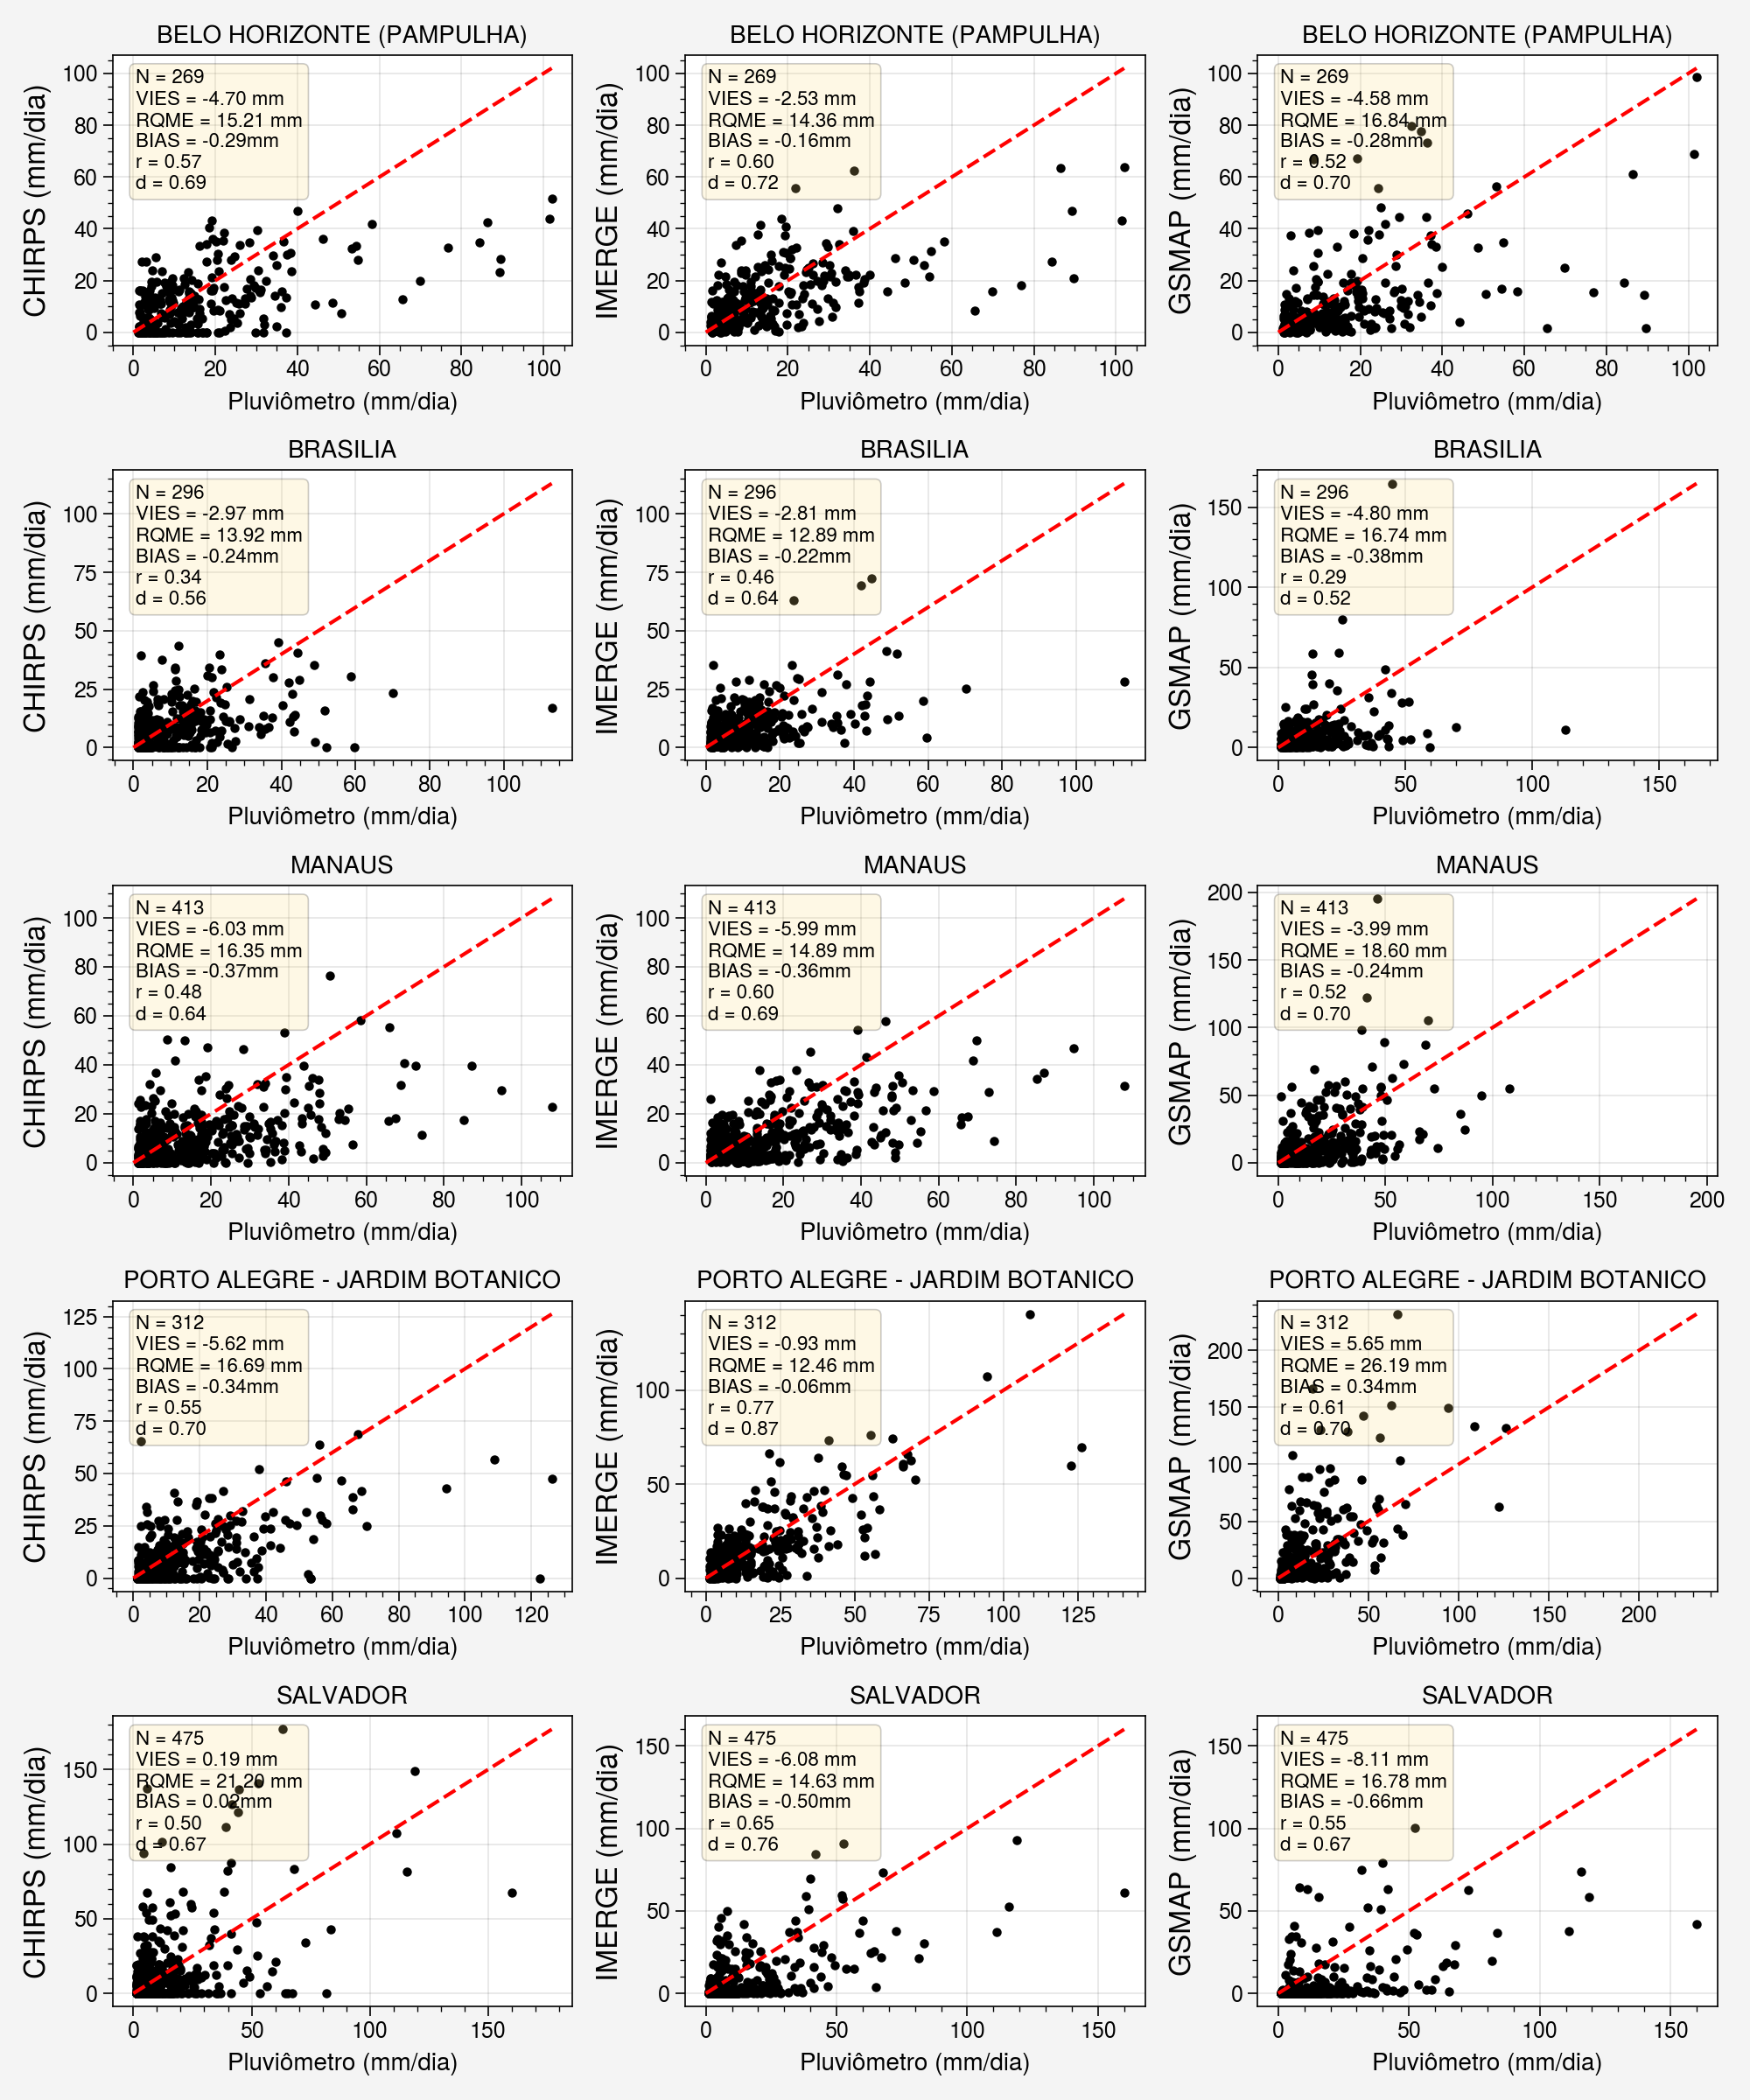

Processo concluído.


In [ ]:

estacoes_coordenadas = {
    'BELO HORIZONTE (PAMPULHA)': {'lat': -19.88, 'lon': -43.96},
    'BRASILIA': {'lat': -15.78, 'lon': -47.92},
    'MANAUS': {'lat': -3.10, 'lon': -60.01},
    'PORTO ALEGRE - JARDIM BOTANICO': {'lat': -30.05, 'lon': -51.17},
    'SALVADOR': {'lat': -13, 'lon': -38.50}
}

# --- ETAPA 2: PREPARAÇÃO DOS DADOS ---
# (Sem alterações aqui)
variaveis_satelite = [var for var in dssat.data_vars if 'precip_' in var]
n_satelites = len(variaveis_satelite)
n_estacoes = len(estacoes_coordenadas)

# --- ETAPA 3: CRIAÇÃO DOS GRÁFICOS (COM LÓGICA ATUALIZADA) ---

fig, axes = plt.subplots(
    nrows=n_estacoes,
    ncols=n_satelites,
    figsize=(10,12),
    squeeze=False
)

print("Gerando gráficos de dispersão com média espacial...")

raio_em_km = 15

resultados_para_tabela = []

for i, (nome_estacao, coords) in enumerate(estacoes_coordenadas.items()):
    lat_estacao = coords['lat']
    lon_estacao = coords['lon']
    dados_estacao = dsest[nome_estacao]
    
    # ### NOVA LÓGICA DE EXTRAÇÃO ###
    # Calcula a variação em graus para o raio desejado
    delta_lat = raio_em_km / 111.0
    delta_lon = raio_em_km / (111.32 * np.cos(np.radians(lat_estacao)))
    
    # Define os limites da caixa (bounding box)
    lat_min = lat_estacao - delta_lat
    lat_max = lat_estacao + delta_lat
    lon_min = lon_estacao - delta_lon
    lon_max = lon_estacao + delta_lon
    
    for j, var_satelite in enumerate(variaveis_satelite):
        ax = axes[i, j]
        
        # Seleciona todos os dados dentro da caixa de coordenadas
        dados_satelite_area = dssat[var_satelite].sel(
            lat=slice(lat_min, lat_max), 
            lon=slice(lon_min, lon_max)
        )
        
        # Calcula a média espacial (sobre as dimensões de latitude e longitude)
        dados_satelite_media = dados_satelite_area.mean(dim=['lat', 'lon'])
        

        # O resto do processo de plotagem é o mesmo de antes
        serie_satelite = dados_satelite_media.to_series()
        
        df_comparacao = pd.DataFrame({
            'estacao': dados_estacao,
            'satelite': serie_satelite
        }).dropna()
        
        df_comparacao = df_comparacao[df_comparacao['estacao'] > 1]
        
        ax.scatter(df_comparacao['estacao'], df_comparacao['satelite'], color= 'black', alpha=1, s=10)
        
        lim_max = max(df_comparacao['estacao'].max(), df_comparacao['satelite'].max())
        ax.plot([0, lim_max], [0, lim_max], 'r--', label='Linha 1:1')

        # ### CÁLCULO E EXIBIÇÃO DAS ESTATÍSTICAS (ATUALIZADO) ###
        if not df_comparacao.empty and len(df_comparacao) > 1:
            # Ei (Estimado) -> Satélite | Oi (Observado) -> Estação
            y_pred = df_comparacao['satelite'] # Ei
            y_true = df_comparacao['estacao']   # Oi

            # --- IMPLEMENTAÇÃO DAS FÓRMULAS DA IMAGEM ---

            # 1. RQME (Raiz do Erro Quadrático Médio) - É o seu RMSE
            # LaTeX: RQME = \sqrt{\frac{\sum_{i=1}^{nd} (E_i - O_i)^2}{nd}}
            rqme = np.sqrt(np.mean((y_pred - y_true)**2))


            # 3. r (Coeficiente de Correlação de Pearson)
            # LaTeX: r = \frac{\sum(E_i - \bar{E})(O_i - \bar{O})}{\sqrt{\sum(E_i - \bar{E})^2 \sum(O_i - \bar{O})^2}}
            correlation = np.corrcoef(y_pred, y_true)[0, 1]

            # 4. VIES (Viés Médio) - É o seu cálculo de BIAS anterior
            # LaTeX: VIES = \frac{\sum(E_i - O_i)}{n}
            vies = np.mean(y_pred - y_true)

            # 5. d (Índice de Concordância de Willmott)
            # LaTeX: d = 1 - \frac{\sum(E_i - O_i)^2}{\sum(|E_i - \bar{O}| + |O_i - \bar{O}|)^2}
            mean_true = np.mean(y_true)
            numerator_d = np.sum((y_pred - y_true)**2)
            denominator_d = np.sum((np.abs(y_pred - mean_true) + np.abs(y_true - mean_true))**2)
            willmott_d = 1 - (numerator_d / denominator_d) if denominator_d != 0 else np.nan

            # Formata o texto que será exibido no gráfico
            stats_text = (
                f"N = {len(df_comparacao)}\n"
                f"VIES = {vies:.2f} mm\n"
                f"RQME = {rqme:.2f} mm\n"
                #f"BIAS = {bias_relativo:.2f}mm\n"
                f"r = {correlation:.2f}\n"
                f"d = {willmott_d:.2f}"
            )
                        ### NOVO: Adiciona os resultados calculados à lista ###
            nome_satelite_limpo = var_satelite.replace('precip_', '').upper()
            resultado_atual = {
                'ESTACAO': nome_estacao,
                'SATELITE': nome_satelite_limpo,
                'N': len(df_comparacao),
                'VIES(mm/dia)': f"{vies:.2f}",
                'RQME(mm/dia)': f"{rqme:.2f}",
                #'BIAS(mm/dia)': f"{bias_relativo:.2f}",
                'CORRELACAO(r)': f"{correlation:.2f}",
                'WILLMOTT(d)': f"{willmott_d:.2f}"
            }
            resultados_para_tabela.append(resultado_atual)
            
            # Adiciona o texto ao gráfico
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.2))

        nome_satelite_limpo = var_satelite.replace('precip_', '').upper()
        ax.set_title(f'{nome_estacao}', fontsize=10,)
        ax.set_xlabel('Pluviômetro (mm/dia)', fontsize=10)
        ax.set_ylabel(f'{nome_satelite_limpo} (mm/dia)', fontsize=12)
        #ax.set_aspect('equal', adjustable='box')
        
        
### NOVO: Seção para criar e salvar o arquivo de texto com a tabela ###
if resultados_para_tabela:
    # Converte a lista de dicionários em um DataFrame do Pandas
    df_resultados = pd.DataFrame(resultados_para_tabela)
    
    # Gera uma string formatada do DataFrame, que se parece com uma tabela
    tabela_em_texto = df_resultados.to_string(index=False)
    
    # Define o nome do arquivo de saída
    nome_arquivo = 'indices_estatisticos_diario.txt'
    
    # Salva a string no arquivo de texto
    with open(nome_arquivo, 'w', encoding='utf-8') as f:
        f.write("Tabela de Índices Estatísticos: Estação vs. Satélite\n")
        f.write("=" * 60 + "\n\n")
        f.write(tabela_em_texto)
    
    print(f"\nArquivo '{nome_arquivo}' gerado com sucesso!")
    print("\nConteúdo do arquivo:")
    print(tabela_em_texto)
else:
    print("\nNenhuma estatística foi calculada para gerar a tabela.")
    
    

plt.tight_layout()
plt.show()

print("Processo concluído.")

Gerando gráficos de dispersão com TOTAIS MENSAIS e todas as métricas...


C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\3794606599.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  totais_mensais_estacao = dados_diarios_estacao.resample('M').sum()
c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\xloko\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
C:\Users\xloko\AppData\Local\Temp\ipykernel_1964\3794606599.py:41: Futur


Arquivo 'indices_estatisticos_mensal.txt' gerado com sucesso!

Conteúdo do arquivo:
                       ESTACAO SATELITE  N VIES(mm/mes) RQME(mm/mes) BIAS(mm/mes) CORRELACAO(r) WILLMOTT(d)
     BELO HORIZONTE (PAMPULHA)   CHIRPS 36       -17.87        38.30        -0.15          0.98        0.98
     BELO HORIZONTE (PAMPULHA)   IMERGE 36        -3.09        35.74        -0.03          0.97        0.98
     BELO HORIZONTE (PAMPULHA)    GSMAP 36       -19.43        67.74        -0.16          0.90        0.93
                      BRASILIA   CHIRPS 36         2.20        34.56         0.02          0.95        0.97
                      BRASILIA   IMERGE 36        -2.48        46.44        -0.02          0.91        0.95
                      BRASILIA    GSMAP 36       -27.10        77.35        -0.26          0.76        0.84
                        MANAUS   CHIRPS 36       -33.86        60.07        -0.18          0.95        0.94
                        MANAUS   IMERGE 36       -4

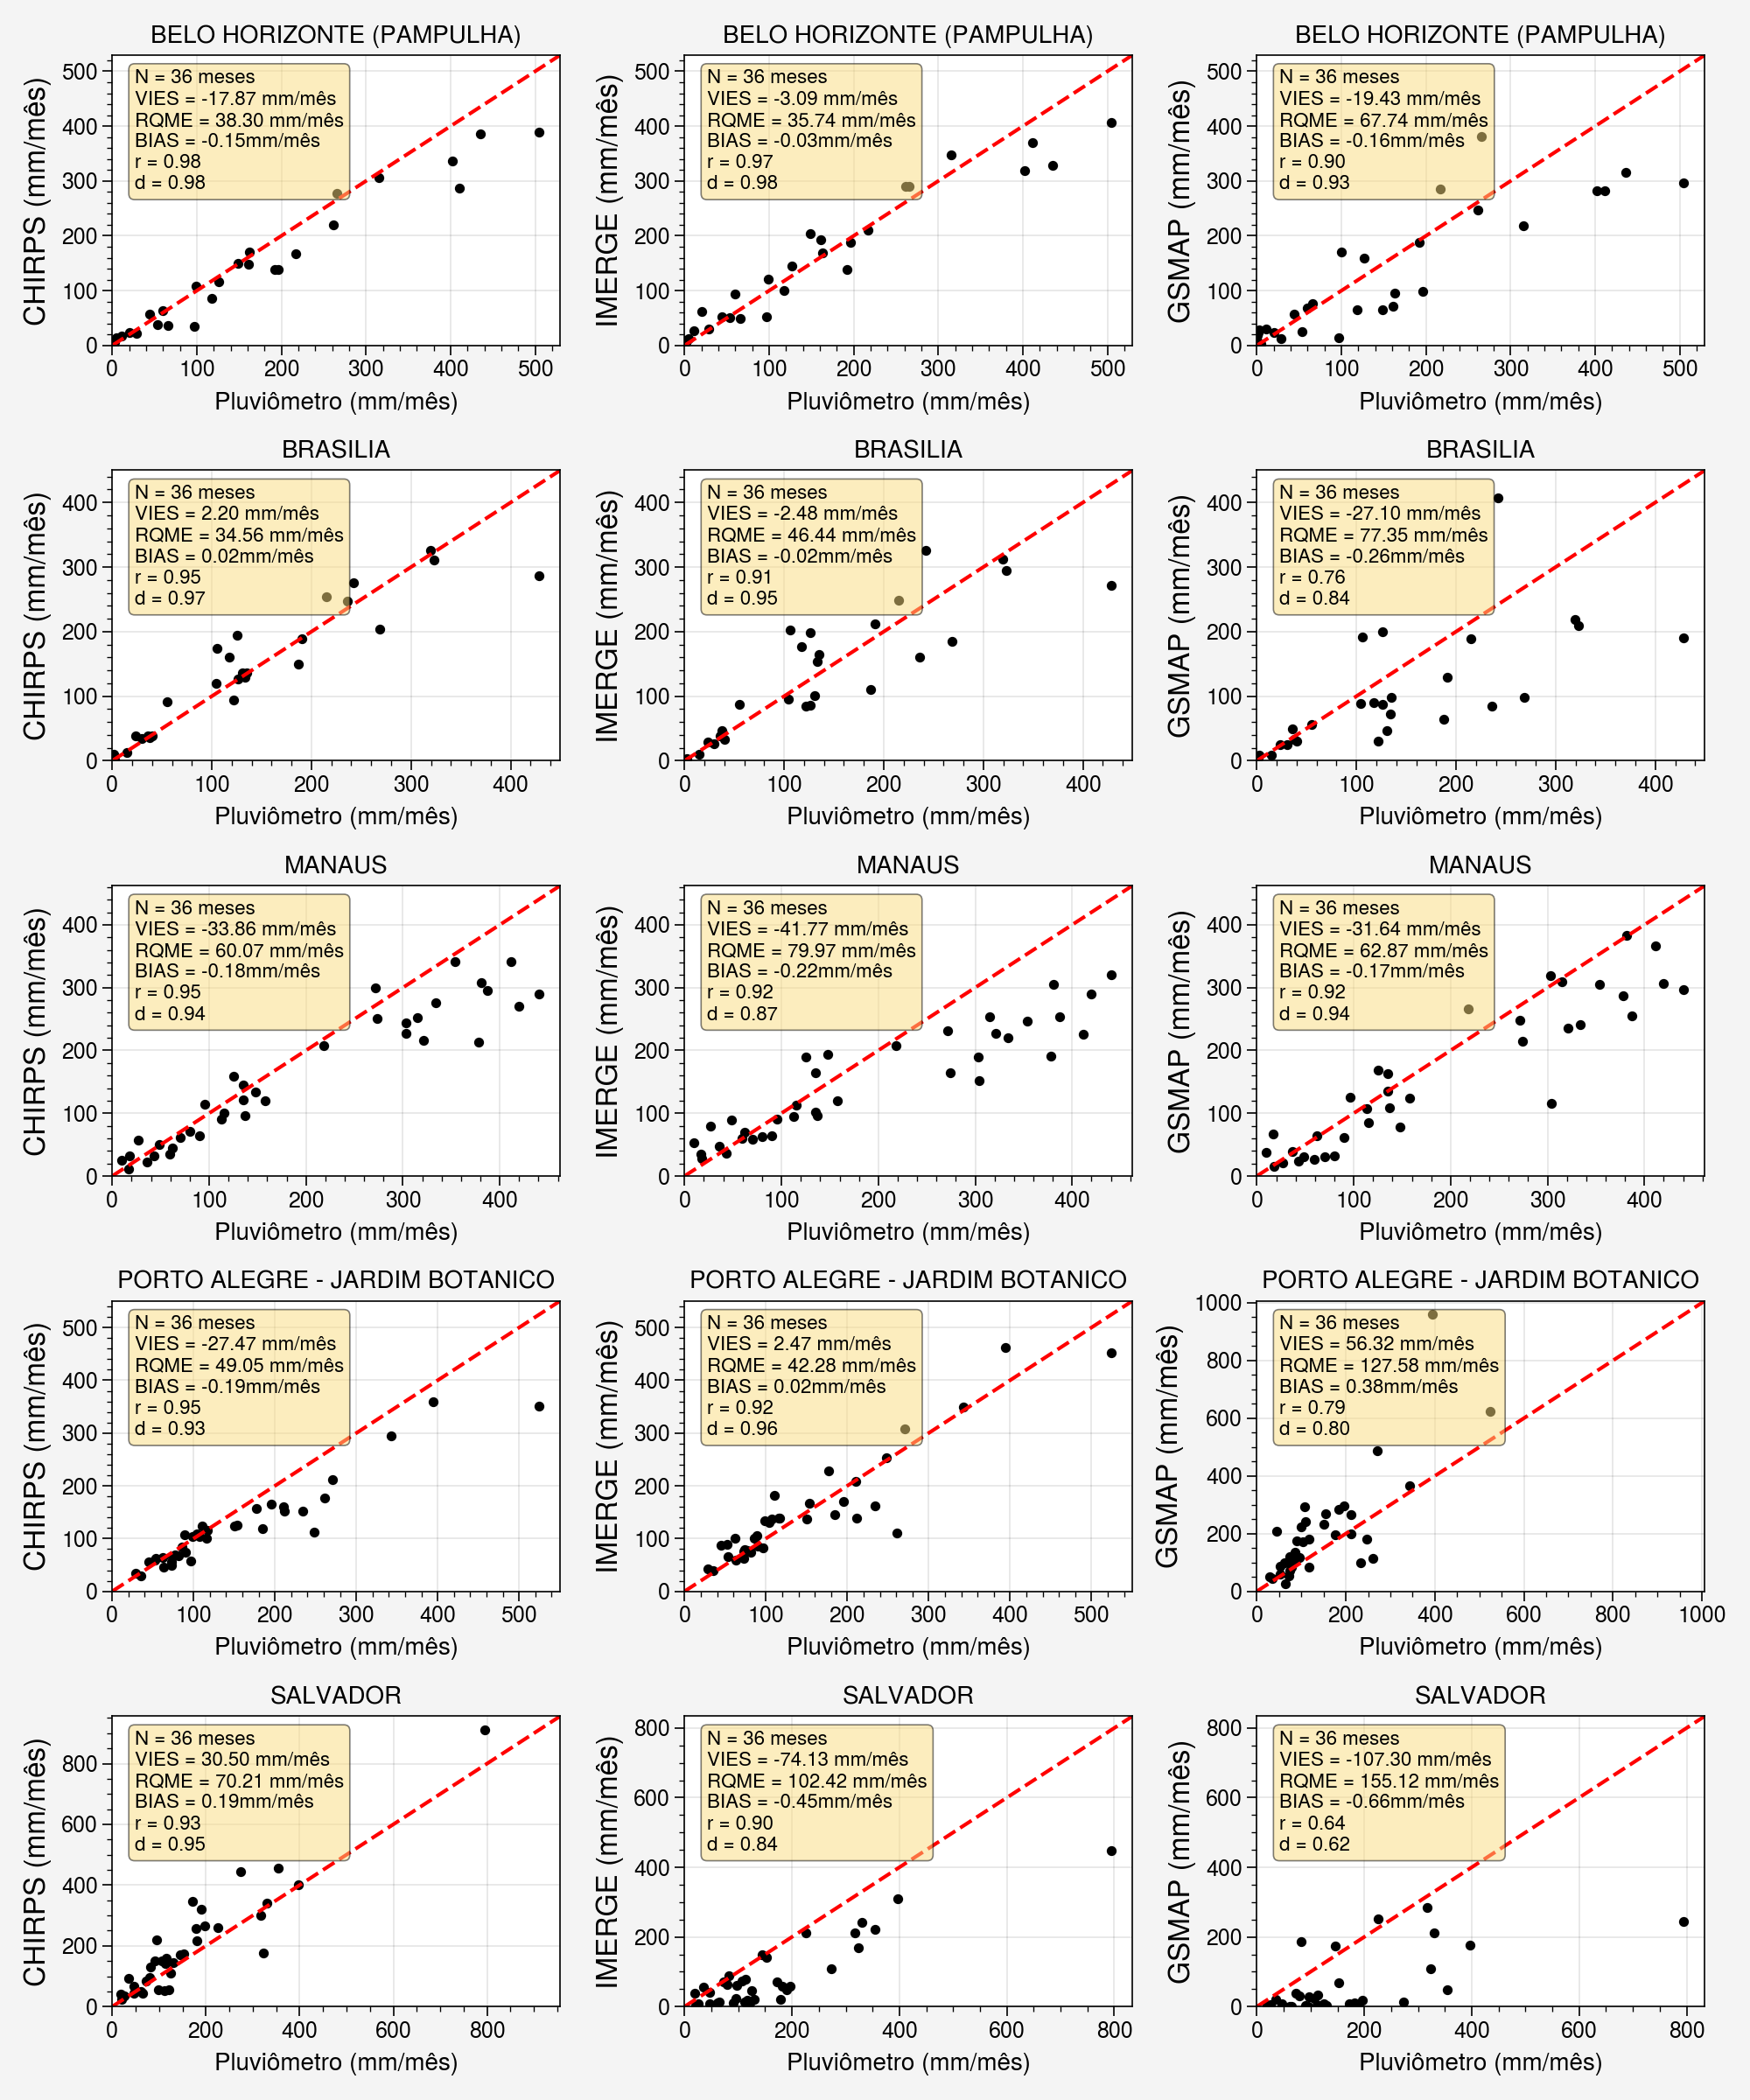

Processo concluído.


In [ ]:
# Importe as bibliotecas necessárias se ainda não o fez

# --- SEU CÓDIGO ANTERIOR (definição de dssat, dsest, etc.) ---
# ... (presume-se que as variáveis dssat, dsest, etc., já existem)

# --- ETAPA 1: DEFINA AS COORDENADAS DAS SUAS ESTAÇÕES ---
estacoes_coordenadas = {
    'BELO HORIZONTE (PAMPULHA)': {'lat': -19.85, 'lon': -43.95},
    'BRASILIA': {'lat': -15.78, 'lon': -47.93},
    'MANAUS': {'lat': -3.10, 'lon': -60.02},
    'PORTO ALEGRE - JARDIM BOTANICO': {'lat': -30.05, 'lon': -51.18},
    'SALVADOR': {'lat': -12.97, 'lon': -38.51}
}

# GARANTE QUE AS DATAS DO DATASET ESTEJAM EM ORDEM
dssat = dssat.sortby('time')

variaveis_satelite = [var for var in dssat.data_vars if 'precip_' in var]
n_satelites = len(variaveis_satelite)
n_estacoes = len(estacoes_coordenadas)

# --- ETAPA 3: CRIAÇÃO DOS GRÁFICOS DE DISPERSÃO MENSAL ---
fig, axes = plt.subplots(
    nrows=n_estacoes,
    ncols=n_satelites,
    figsize=(10, 12),
    squeeze=False
)

print("Gerando gráficos de dispersão com TOTAIS MENSAIS e todas as métricas...")

raio_em_km = 15.0

resultados_para_tabela = []

for i, (nome_estacao, coords) in enumerate(estacoes_coordenadas.items()):
    lat_estacao = coords['lat']
    lon_estacao = coords['lon']
    
    dados_diarios_estacao = dsest[nome_estacao]
    totais_mensais_estacao = dados_diarios_estacao.resample('M').sum()

    delta_lat = raio_em_km / 111.0
    delta_lon = raio_em_km / (111.32 * np.cos(np.radians(lat_estacao)))
    lat_min, lat_max = lat_estacao - delta_lat, lat_estacao + delta_lat
    lon_min, lon_max = lon_estacao - delta_lon, lon_estacao + delta_lon
    
    for j, var_satelite in enumerate(variaveis_satelite):
        ax = axes[i, j]
        
        dados_satelite_area = dssat[var_satelite].sel(
            lat=slice(lat_min, lat_max), 
            lon=slice(lon_min, lon_max)
        )
        dados_diarios_satelite = dados_satelite_area.mean(dim=['lat', 'lon'])
        totais_mensais_satelite = dados_diarios_satelite.resample(time='M').sum()
        
        serie_satelite_mensal = totais_mensais_satelite.to_series()
        
        df_comparacao = pd.DataFrame({
            'estacao': totais_mensais_estacao,
            'satelite': serie_satelite_mensal
        }).dropna()
        
        ax.scatter(df_comparacao['estacao'], df_comparacao['satelite'], color='black', alpha=1, s=12)
        
        # --- LÓGICA DE PLOTAGEM E CÁLCULO ATUALIZADA ---
        lim_max = 1 # Valor padrão caso não haja dados
        if not df_comparacao.empty:
            lim_max = max(df_comparacao['estacao'].max(), df_comparacao['satelite'].max())
        
        ax.plot([0, lim_max * 1.05], [0, lim_max * 1.05], 'r--', label='Linha 1:1') # Adicionado um pequeno buffer de 5%
        ax.set_xlim(0, lim_max * 1.05)
        ax.set_ylim(0, lim_max * 1.05)

        # ### CÁLCULO E EXIBIÇÃO DAS ESTATÍSTICAS (ATUALIZADO) ###
        if not df_comparacao.empty and len(df_comparacao) > 1:
            # Ei (Estimado) -> Satélite | Oi (Observado) -> Estação
            y_pred = df_comparacao['satelite'] # Ei
            y_true = df_comparacao['estacao']   # Oi

            # --- IMPLEMENTAÇÃO DAS FÓRMULAS DA IMAGEM ---
            rqme = np.sqrt(np.mean((y_pred - y_true)**2))
            sum_true = np.sum(y_true)
            bias_relativo = (np.sum(y_pred) - sum_true) / sum_true if sum_true != 0 else np.nan
            correlation = np.corrcoef(y_pred, y_true)[0, 1]
            vies = np.mean(y_pred - y_true)
            mean_true = np.mean(y_true)
            numerator_d = np.sum((y_pred - y_true)**2)
            denominator_d = np.sum((np.abs(y_pred - mean_true) + np.abs(y_true - mean_true))**2)
            willmott_d = 1 - (numerator_d / denominator_d) if denominator_d != 0 else np.nan
            
            # Formata o texto que será exibido no gráfico
            stats_text = (
                f"N = {len(df_comparacao)} meses\n"
                f"VIES = {vies:.2f} mm/mês\n"
                f"RQME = {rqme:.2f} mm/mês\n"
                #f"BIAS = {bias_relativo:.2f}mm/mês\n"
                f"r = {correlation:.2f}\n"
                f"d = {willmott_d:.2f}"
            )
                        ### NOVO: Adiciona os resultados calculados à lista ###
            nome_satelite_limpo = var_satelite.replace('precip_', '').upper()
            resultado_atual = {
                'ESTACAO': nome_estacao,
                'SATELITE': nome_satelite_limpo,
                'N': len(df_comparacao),
                'VIES(mm/mes)': f"{vies:.2f}",
                'RQME(mm/mes)': f"{rqme:.2f}",
                #'BIAS(mm/mes)': f"{bias_relativo:.2f}",
                'CORRELACAO(r)': f"{correlation:.2f}",
                'WILLMOTT(d)': f"{willmott_d:.2f}"
            }
            resultados_para_tabela.append(resultado_atual)
            
            # Adiciona o texto ao gráfico
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

        nome_satelite_limpo = var_satelite.replace('precip_', '').upper()
        ax.set_title(f'{nome_estacao}', fontsize=10,)
        # CORREÇÃO: Unidade alterada para mm/mês
        ax.set_xlabel('Pluviômetro (mm/mês)', fontsize=10)
        ax.set_ylabel(f'{nome_satelite_limpo} (mm/mês)', fontsize=12)

        
### NOVO: Seção para criar e salvar o arquivo de texto com a tabela ###
if resultados_para_tabela:
    # Converte a lista de dicionários em um DataFrame do Pandas
    df_resultados = pd.DataFrame(resultados_para_tabela)
    
    # Gera uma string formatada do DataFrame, que se parece com uma tabela
    tabela_em_texto = df_resultados.to_string(index=False)
    
    # Define o nome do arquivo de saída
    nome_arquivo = 'indices_estatisticos_mensal.txt'
    
    # Salva a string no arquivo de texto
    with open(nome_arquivo, 'w', encoding='utf-8') as f:
        f.write("Tabela de Índices Estatísticos: Estação vs. Satélite\n")
        f.write("=" * 60 + "\n\n")
        f.write(tabela_em_texto)
    
    print(f"\nArquivo '{nome_arquivo}' gerado com sucesso!")
    print("\nConteúdo do arquivo:")
    print(tabela_em_texto)
else:
    print("\nNenhuma estatística foi calculada para gerar a tabela.")

plt.tight_layout()
plt.show()

print("Processo concluído.")

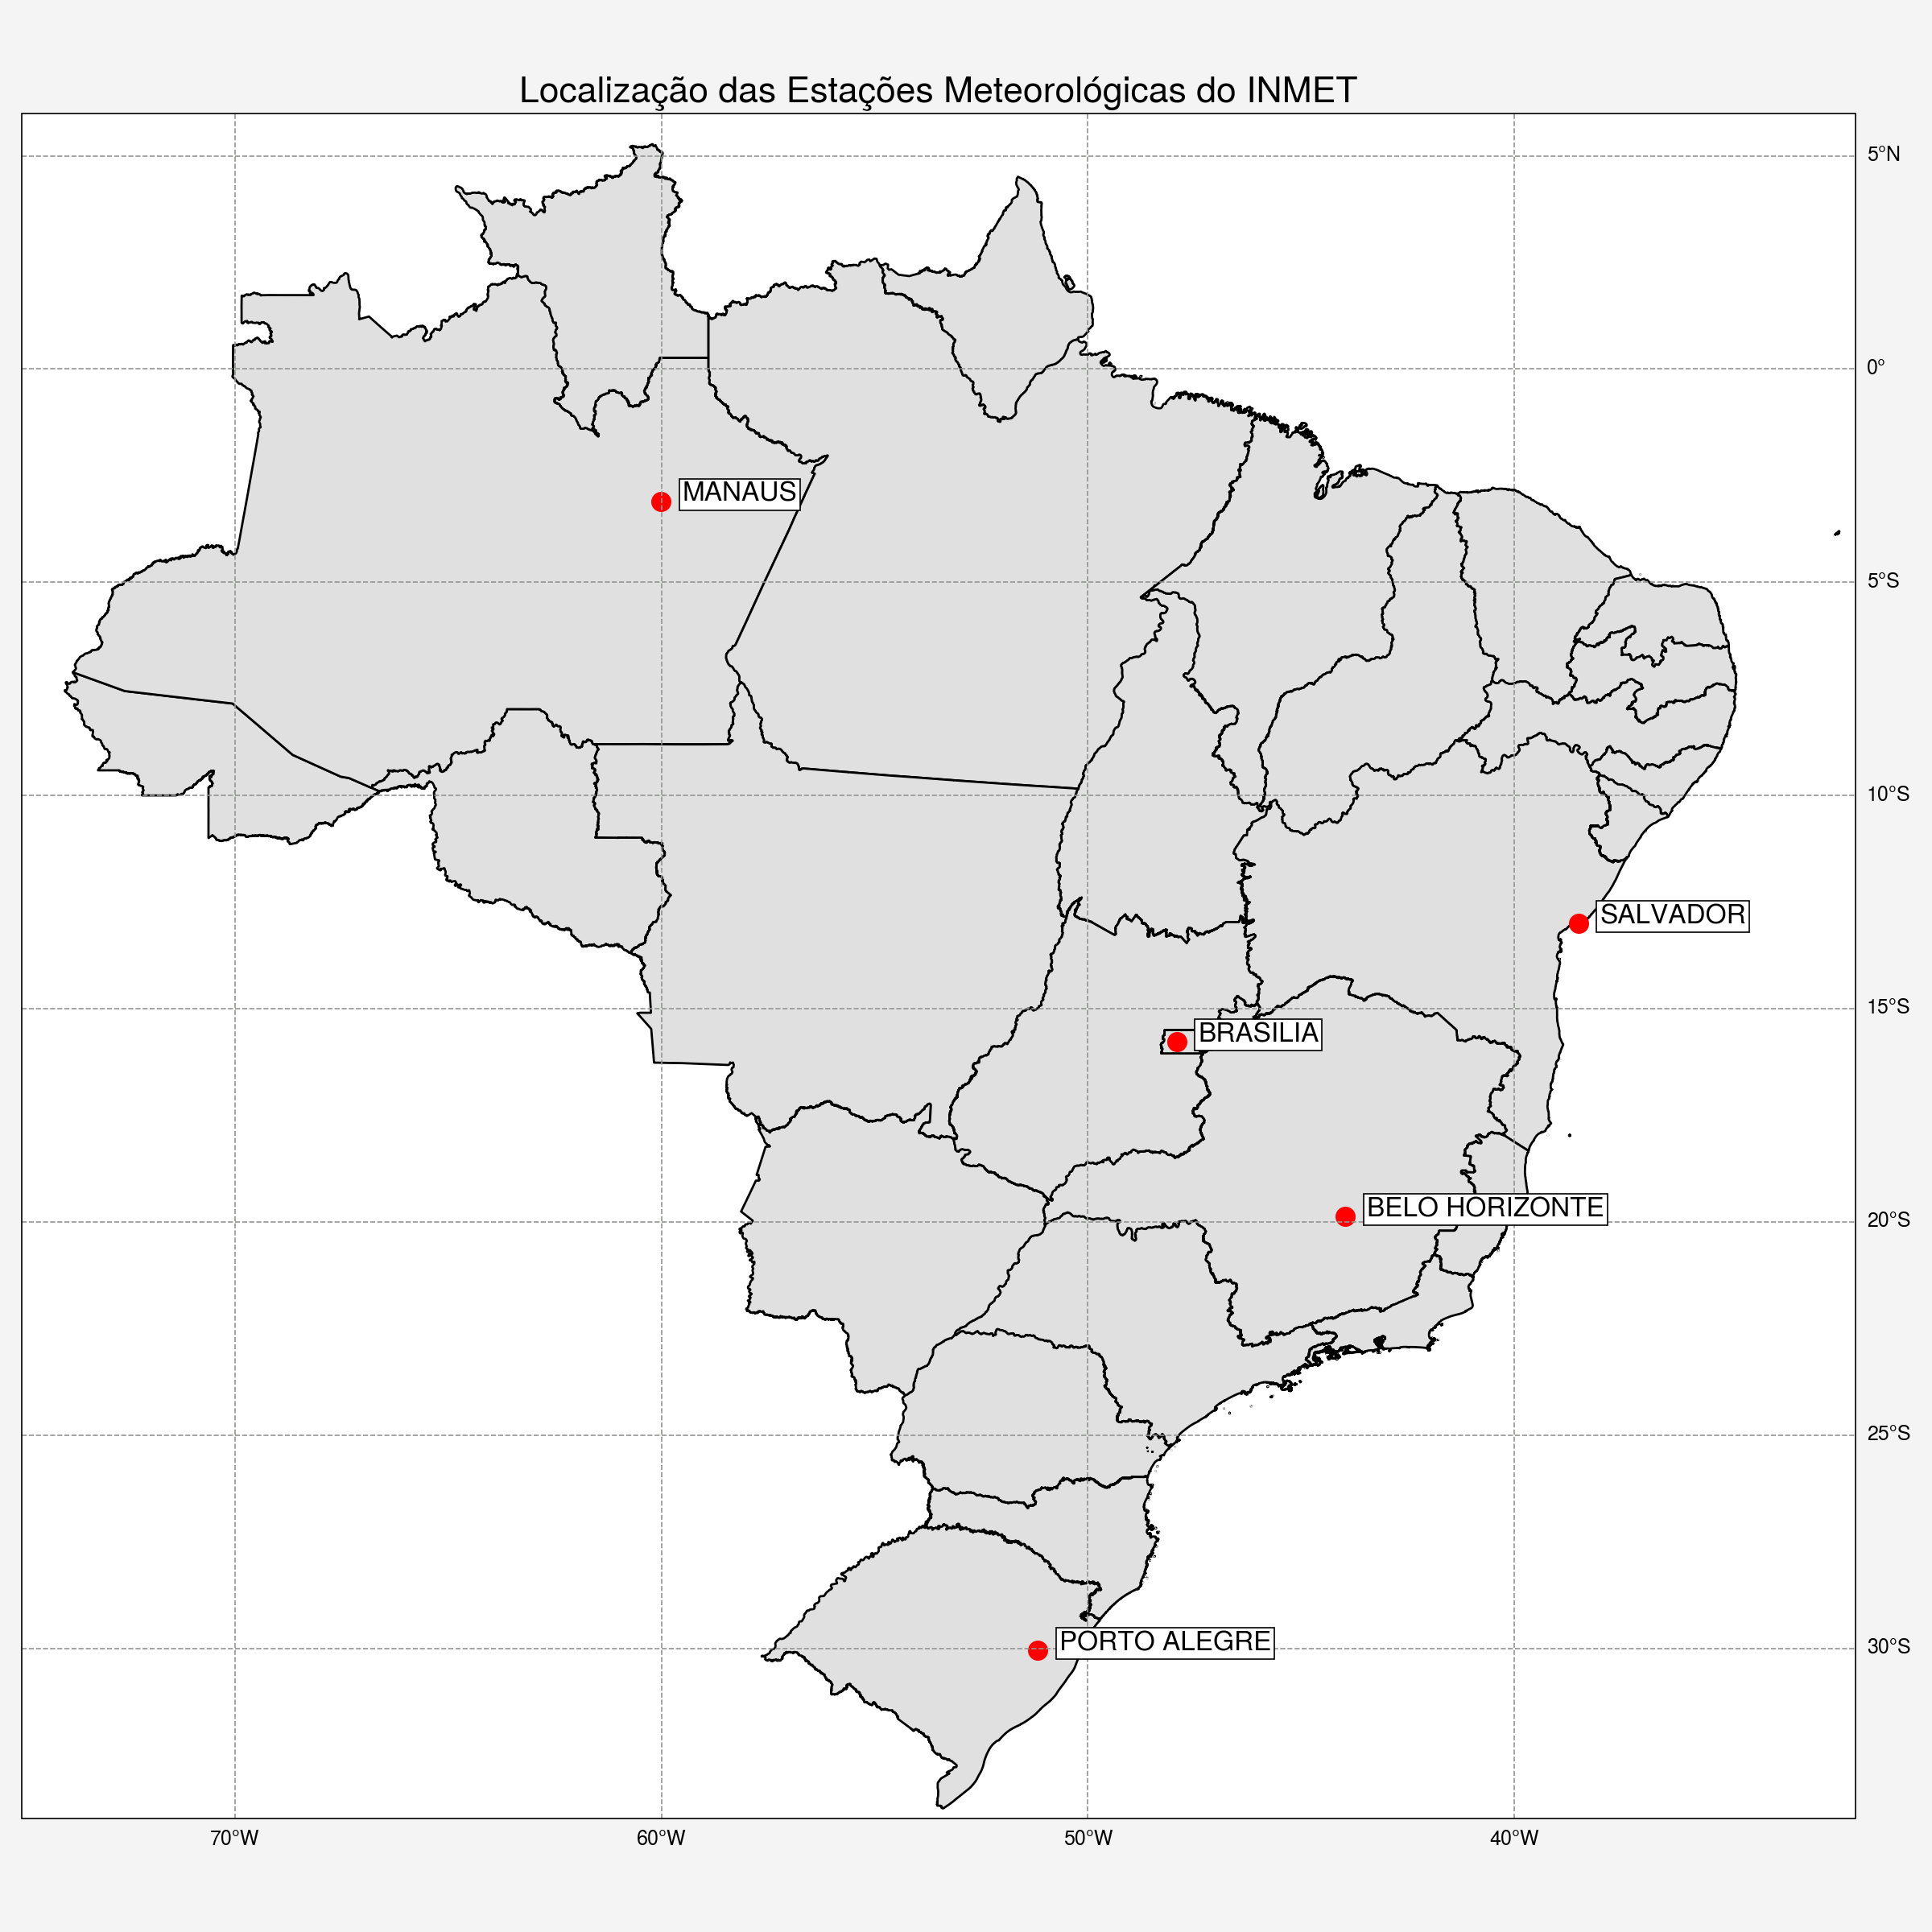

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

# Dicionário com as coordenadas das estações
estacoes_coordenadas = {
    'BELO HORIZONTE': {'lat': -19.88, 'lon': -43.96},
    'BRASILIA': {'lat': -15.78, 'lon': -47.92},
    'MANAUS': {'lat': -3.10, 'lon': -60.01},
    'PORTO ALEGRE': {'lat': -30.05, 'lon': -51.17},
    'SALVADOR': {'lat': -13, 'lon': -38.50}
}

# --- Configuração do Mapa com Cartopy ---

# Cria a figura e os eixos com a projeção PlateCarree (padrão para lat/lon)
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Define a extensão do mapa para focar no Brasil
# formato: [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-75, -32, -34, 6], crs=ccrs.PlateCarree())


# --- Carregando e Plotando o Shapefile dos Estados ---

# URL para o arquivo .shp
shapefile_url = 'https://github.com/evmpython/CAT010_UNIFEI_2024/raw/main/shapefiles/BR_UF_2019.shp'

# Lê as geometrias do shapefile a partir da URL
# A biblioteca vai buscar os arquivos associados (.shx, .dbf) no mesmo diretório
shapefile = list(shpreader.Reader(shapefile_url).geometries())

# Adiciona as geometrias (os estados) ao mapa
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='#E0E0E0', linewidth=1.0)


# --- Plotando as Estações ---

# Itera sobre o dicionário de estações para plotar cada uma
for nome_estacao, coords in estacoes_coordenadas.items():
    lon = coords['lon']
    lat = coords['lat']
    
    # Plota o ponto da estação
    # O argumento 'transform' é crucial para dizer ao cartopy que as coordenadas são lat/lon
    ax.plot(lon, lat,
            marker='o',              # Estilo do marcador
            color='red',             # Cor
            markersize=8,            # Tamanho
            transform=ccrs.PlateCarree())
            
    # Adiciona o texto com o nome da estação
    ax.text(lon + 0.5, lat, nome_estacao,
            fontsize=12,
            color='black',
            bbox=dict(facecolor='white', alpha=1, pad=1.5),
            transform=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')
gl.top_labels = False
gl.left_labels = False

# Adiciona um título
ax.set_title("Localização das Estações Meteorológicas do INMET", fontsize=16)
# Adicione esta linha antes de mostrar
plt.tight_layout()
# Mostra o mapa
plt.show()